In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
import sklearn.metrics as skm
import sklearn.model_selection as skms
import sklearn.preprocessing as skp
import random
import librosa, IPython
import librosa.display as lplt
seed = 12
np.random.seed(seed)
import tensorflow as tf
import keras as k
tf.random.set_seed(seed)

import import_ipynb
import nbimporter
from utils import trainModel,plotHistory, Grafico_Confronto_NN

In [63]:
# Caricare i dati dal CSV
file_path = 'Data/features_3_sec.csv'
df = pd.read_csv(file_path)

In [3]:
# find all columns with any NA values
#print("Columns with NA values are",list(df.columns[df.isnull().any()]))

Columns with NA values are []


In [64]:
# map labels to index
label_index = dict()
index_label = dict()
for i, x in enumerate(df.label.unique()):
    label_index[x] = i
    index_label[i] = x
print(label_index)
print(index_label)

{'blues': 0, 'classical': 1, 'country': 2, 'disco': 3, 'hiphop': 4, 'jazz': 5, 'metal': 6, 'pop': 7, 'reggae': 8, 'rock': 9}
{0: 'blues', 1: 'classical', 2: 'country', 3: 'disco', 4: 'hiphop', 5: 'jazz', 6: 'metal', 7: 'pop', 8: 'reggae', 9: 'rock'}


In [65]:
# update labels in df to index
df.label = [label_index[l] for l in df.label]

In [66]:
# shuffle samples
df_shuffle = df.sample(frac=1, random_state=seed).reset_index(drop=True)

In [67]:
# remove irrelevant columns
df_shuffle.drop(['filename', 'length'], axis=1, inplace=True)
df_y = df_shuffle.pop('label')
df_X = df_shuffle

# split into train dev and test
X_train, df_test_valid_X, y_train, df_test_valid_y = skms.train_test_split(df_X, df_y, train_size=0.7, random_state=seed, stratify=df_y)
X_dev, X_test, y_dev, y_test = skms.train_test_split(df_test_valid_X, df_test_valid_y, train_size=0.66, random_state=seed, stratify=df_test_valid_y)

In [70]:
scaler = skp.StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_dev = pd.DataFrame(scaler.transform(X_dev), columns=X_train.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_train.columns)

PRIMO MODELLO, MODELLO DI BASE PER VEDERE LE STATISTICHE

In [24]:
model_1 = k.models.Sequential([
    k.layers.Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    k.layers.Dense(128, activation='relu'),
    k.layers.Dense(64, activation='relu'),
    k.layers.Dense(10, activation='softmax'),
])
print(model_1.summary())


model_1_history = trainModel(model=model_1, X_train=X_train, y_train=y_train, 
                             X_dev=X_dev, y_dev=y_dev, epochs=70, optimizer='adam')

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 256)            │        15,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,906 (222.29 KB)

 Trainable params: 56,906 (222.29 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/70
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.3704 - loss: 1.7877 - val_accuracy: 0.6234 - val_loss: 1.0563
Epoch 2/70
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6698 - loss: 0.9533 - val_accuracy: 0.7098 - val_loss: 0.8233
Epoch 3/70
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7558 - loss: 0.7279 - val_accuracy: 0.7528 - val_loss: 0.7097
Epoch 4/70
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8002 - loss: 0.6001 - val_accuracy: 0.7897 - val_loss: 0.6324
Epoch 5/70
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8300 - loss: 0.5059 - val_accuracy: 0.8059 - val_loss: 0.5786
Epoch 6/70
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8610 - loss: 0.4292 - val_accuracy: 0.8160 - val_loss: 0.5450
Epoch 7/70
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8826 - loss: 0.3672 - val_accuracy: 0.8241 - val_loss: 0.5291
Epoch 8/70
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9028 - loss: 0.3190 - val_accuracy: 0.8296 - val

Max. Validation Accuracy 0.8993933200836182


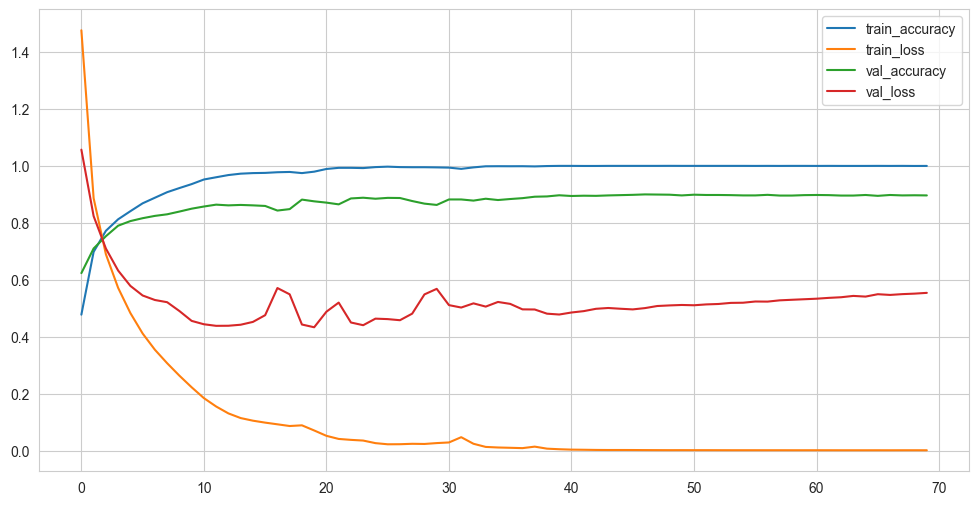

In [25]:
plotHistory(model_1_history)

In [27]:
test_loss, nn1  = model_1.evaluate(X_test, y_test, batch_size=128)
print("The test Loss is :",test_loss)
print("\nThe Best test Accuracy is :",nn1*100)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8863 - loss: 0.6545
The test Loss is : 0.6572433710098267

The Best test Accuracy is : 88.61628770828247


Secondo modello, ho lavorato con il dropout per una migliore generalizzazione

In [12]:
model_2 = k.models.Sequential([
    k.layers.Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    k.layers.Dropout(0.2),
    
    k.layers.Dense(256, activation='relu'),
    k.layers.Dropout(0.2),

    k.layers.Dense(128, activation='relu'),
    k.layers.Dropout(0.2),

    k.layers.Dense(64, activation='relu'),
    k.layers.Dropout(0.2),

    k.layers.Dense(10, activation='softmax'),
])
print(model_2.summary())


model_2_history = trainModel(model=model_2, X_train=X_train, y_train=y_train, 
                             X_dev=X_dev, y_dev=y_dev, epochs=100, optimizer='adam')


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │        30,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,338 (794.29 KB)

 Trainable params: 203,338 (794.29 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.3091 - loss: 1.9008 - val_accuracy: 0.6163 - val_loss: 1.1062
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6023 - loss: 1.1524 - val_accuracy: 0.7164 - val_loss: 0.8322
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6806 - loss: 0.9336 - val_accuracy: 0.7518 - val_loss: 0.7223
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7238 - loss: 0.8081 - val_accuracy: 0.7730 - val_loss: 0.6533
Epoch 5/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7618 - loss: 0.7184 - val_accuracy: 0.7983 - val_loss: 0.5788
Epoch 6/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7729 - loss: 0.6453 - val_accuracy: 0.8241 - val_loss: 0.5317
Epoch 7/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8016 - loss: 0.5686 - val_accuracy: 0.8438 - val_loss: 0.4843
Epoch 8/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8235 - loss: 0.5177 - val_accurac

Max. Validation Accuracy 0.930738091468811


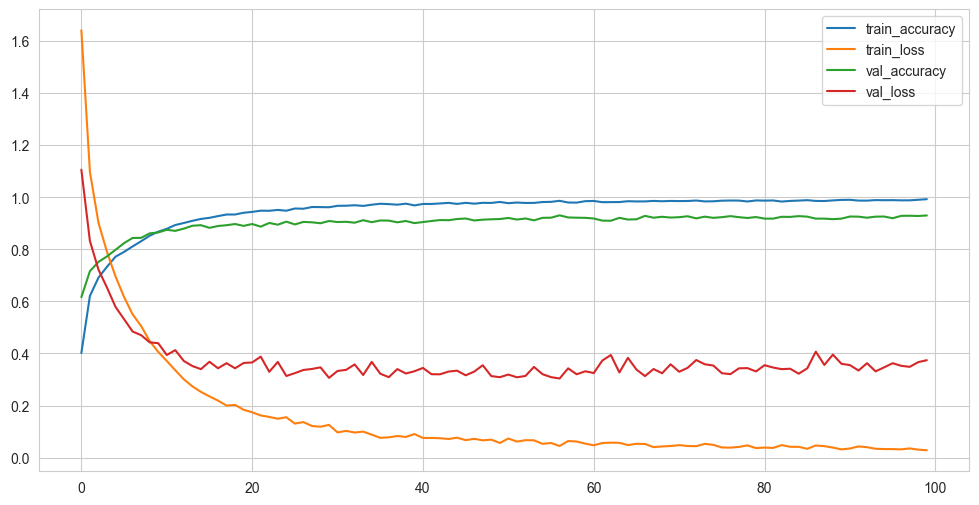

In [13]:
plotHistory(model_2_history)

In [14]:
test_loss, nn2  = model_2.evaluate(X_test, y_test, batch_size=128)
print("The test Loss is :",test_loss)
print("\nThe Best test Accuracy is :",nn2*100)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9272 - loss: 0.3659
The test Loss is : 0.385102778673172

The Best test Accuracy is : 92.34543442726135


modello 6 provo a mettere la batch normalization

In [100]:
model_6 = k.models.Sequential([
    k.layers.Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    k.layers.BatchNormalization(),
    k.layers.Dropout(0.2),
    k.layers.Dense(256, activation='relu'),
    k.layers.BatchNormalization(),
    k.layers.Dropout(0.2),
    k.layers.Dense(128, activation='relu'),
    k.layers.BatchNormalization(),
    k.layers.Dropout(0.2),
    k.layers.Dense(64, activation='relu'),
    k.layers.BatchNormalization(),
    k.layers.Dropout(0.2),
    k.layers.Dense(10, activation='softmax'),
])
print(model_6.summary())
model_6_history = trainModel(model=model_6, X_train=X_train, y_train=y_train, 
                             X_dev=X_dev, y_dev=y_dev, epochs=50, optimizer='rmsprop')

Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_135 (Dense)               │ (None, 512)            │        29,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_103 (Dropout)           │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_136 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_44          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_104 (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_137 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_105 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_138 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_46          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_106 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_139 (Dense)               │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 206,666 (807.29 KB)

 Trainable params: 204,746 (799.79 KB)

 Non-trainable params: 1,920 (7.50 KB)

None
Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.4036 - loss: 1.8415 - val_accuracy: 0.6613 - val_loss: 1.3826
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6452 - loss: 1.0309 - val_accuracy: 0.7371 - val_loss: 0.9705
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7181 - loss: 0.8311 - val_accuracy: 0.7700 - val_loss: 0.7439
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7609 - loss: 0.7005 - val_accuracy: 0.7867 - val_loss: 0.6316
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7916 - loss: 0.6251 - val_accuracy: 0.8145 - val_loss: 0.5421
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8134 - loss: 0.5493 - val_accuracy: 0.8316 - val_loss: 0.4844
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8295 - loss: 0.4959 - val_accuracy: 0.8448 - val_loss: 0.4544
Epoch 8/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8481 - loss: 0.4401 - val_accuracy: 0.850

Max. Validation Accuracy 0.9180991053581238


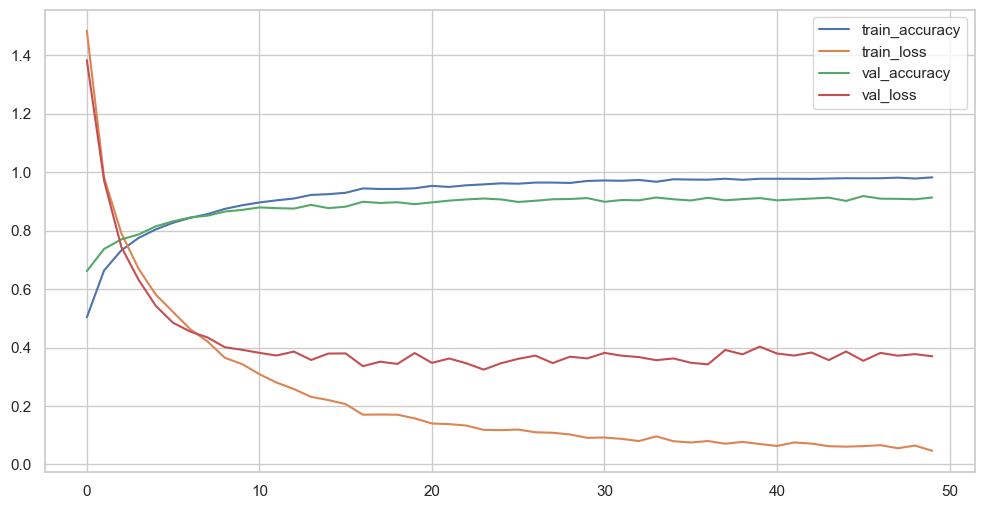

In [101]:
plotHistory(model_6_history)

In [103]:
test_loss, nn6 = model_6.evaluate(X_test, y_test, batch_size=128)
print("The test Loss is :",test_loss)
print("\nThe Best test Accuracy is :",nn6 *100)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9132 - loss: 0.3769
The test Loss is : 0.38269609212875366

The Best test Accuracy is : 90.97154140472412


modello 7 provo a usare nuovo ottimizzatore adam, migliori risultati, buoa loss


In [72]:
model_7 = k.models.Sequential([
    k.layers.Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    k.layers.BatchNormalization(),
    k.layers.Dropout(0.4),
    k.layers.Dense(256, activation='relu'),
    k.layers.BatchNormalization(),
    k.layers.Dropout(0.4),
    k.layers.Dense(128, activation='relu'),
    k.layers.BatchNormalization(),
    k.layers.Dropout(0.4),
    k.layers.Dense(64, activation='relu'),
    k.layers.BatchNormalization(),
    k.layers.Dropout(0.4),
    k.layers.Dense(10, activation='softmax'),
])
print(model_7.summary())
model_7_history = trainModel(model=model_7, X_train=X_train, y_train=y_train, 
                             X_dev=X_dev, y_dev=y_dev, epochs=100, optimizer='adam')

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_105 (Dense)               │ (None, 512)            │        29,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_79 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_106 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_80 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_107 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_81 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_108 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_82 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_109 (Dense)               │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 206,666 (807.29 KB)

 Trainable params: 204,746 (799.79 KB)

 Non-trainable params: 1,920 (7.50 KB)

None
Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.2195 - loss: 2.5885 - val_accuracy: 0.5207 - val_loss: 1.5618
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4284 - loss: 1.6214 - val_accuracy: 0.6249 - val_loss: 1.2256
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5295 - loss: 1.3494 - val_accuracy: 0.6572 - val_loss: 1.0479
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5957 - loss: 1.1802 - val_accuracy: 0.6866 - val_loss: 0.9280
Epoch 5/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6162 - loss: 1.0984 - val_accuracy: 0.7154 - val_loss: 0.8304
Epoch 6/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6541 - loss: 1.0183 - val_accuracy: 0.7305 - val_loss: 0.7618
Epoch 7/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6822 - loss: 0.9433 - val_accuracy: 0.7568 - val_loss: 0.7027
Epoch 8/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7066 - loss: 0.8910 - val_accurac

Max. Validation Accuracy 0.9226491451263428


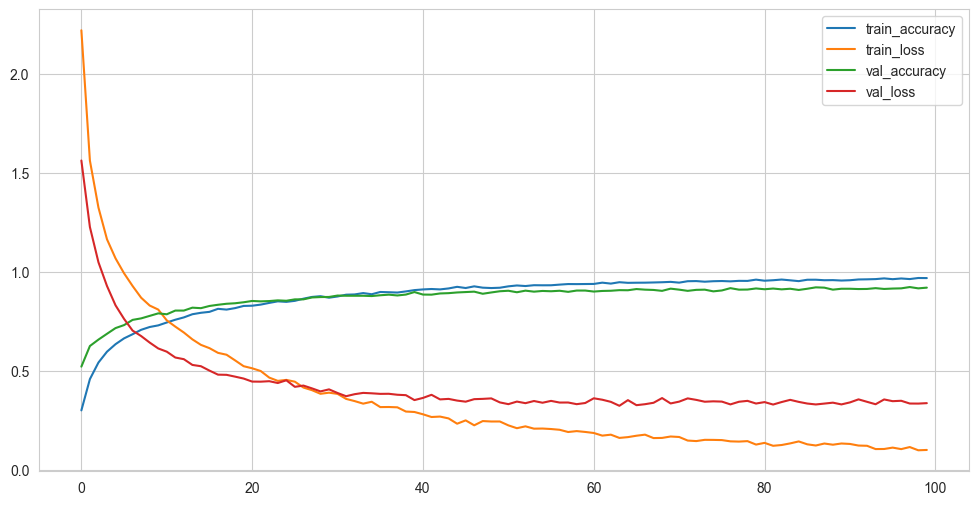

In [73]:
plotHistory(model_7_history)

In [106]:
test_loss, nn7 = model_7.evaluate(X_test, y_test, batch_size=128)
nn=test_loss
print("The test Loss is :",test_loss)
print("\nThe Best test Accuracy is :", nn7 *100)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9272 - loss: 0.3066 
The test Loss is : 0.315852552652359

The Best test Accuracy is : 92.63984560966492


modello 9: provo a cambiare le funzioni di attivazione. Ottimo con 100 epoche

ha meno lossdi tutti

In [92]:
model_10 = k.models.Sequential([
    k.layers.Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    k.layers.Dropout(0.4),
    
    k.layers.Dense(256, activation='relu'),
    k.layers.Dropout(0.4),

    k.layers.Dense(128, activation='relu'),
    k.layers.Dropout(0.4),

    k.layers.Dense(64, activation='relu'),
    k.layers.Dropout(0.4),

    k.layers.Dense(10, activation='softmax'),
])
print(model_10.summary())
model_10_history = trainModel(model=model_10, X_train=X_train, y_train=y_train, 
                             X_dev=X_dev, y_dev=y_dev, epochs=100, optimizer='adam')

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_125 (Dense)               │ (None, 512)            │        29,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_95 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_126 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_96 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_127 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_97 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_98 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_129 (Dense)               │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 202,826 (792.29 KB)

 Trainable params: 202,826 (792.29 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.1889 - loss: 2.2011 - val_accuracy: 0.4616 - val_loss: 1.5131
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3988 - loss: 1.6599 - val_accuracy: 0.5647 - val_loss: 1.2357
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4970 - loss: 1.4120 - val_accuracy: 0.6229 - val_loss: 1.0729
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5555 - loss: 1.2723 - val_accuracy: 0.6855 - val_loss: 0.9255
Epoch 5/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6220 - loss: 1.1157 - val_accuracy: 0.7123 - val_loss: 0.8446
Epoch 6/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6524 - loss: 1.0496 - val_accuracy: 0.7406 - val_loss: 0.7736
Epoch 7/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6823 - loss: 0.9756 - val_accuracy: 0.7568 - val_loss: 0.7233
Epoch 8/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6982 - loss: 0.9059 - val_accuracy

In [93]:
test_loss, nn10 = model_10.evaluate(X_test, y_test, batch_size=128)
print("The test Loss is :",test_loss)
print("\nThe Best test Accuracy is :", nn10*100)




#####DEVO PROVARE CON 400 E 500 EPOCHEEEEEEEEEEE

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9107 - loss: 0.2867
The test Loss is : 0.3256857097148895

The Best test Accuracy is : 90.77526926994324


Max. Validation Accuracy 0.9231547117233276


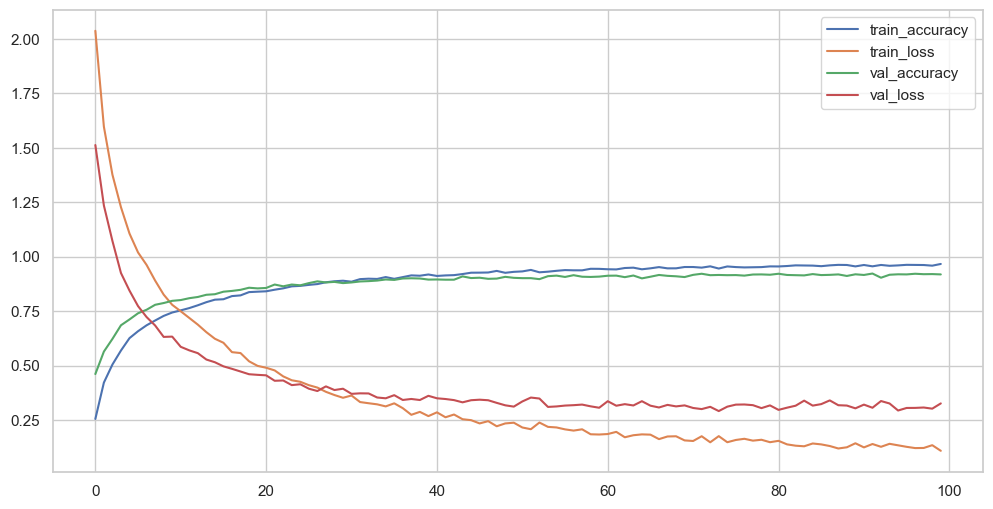

In [94]:
plotHistory(model_10_history)

UGUALE A QUELLA SOPRA RMSPROP INVECE CHE ADAM COME OTTIMIZZATORE


In [96]:
model_11 = k.models.Sequential([
    k.layers.Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    k.layers.Dropout(0.4),
    
    k.layers.Dense(256, activation='relu'),
    k.layers.Dropout(0.4),

    k.layers.Dense(128, activation='relu'),
    k.layers.Dropout(0.4),

    k.layers.Dense(64, activation='relu'),
    k.layers.Dropout(0.4),

    k.layers.Dense(10, activation='softmax'),
])
print(model_11.summary())
model_11_history = trainModel(model=model_11, X_train=X_train, y_train=y_train, 
                             X_dev=X_dev, y_dev=y_dev, epochs=100, optimizer='rmsprop')

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_130 (Dense)               │ (None, 512)            │        29,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_99 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_131 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_100 (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_132 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_101 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_133 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_102 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_134 (Dense)               │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 202,826 (792.29 KB)

 Trainable params: 202,826 (792.29 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.2347 - loss: 2.0992 - val_accuracy: 0.5202 - val_loss: 1.3942
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4219 - loss: 1.5914 - val_accuracy: 0.5971 - val_loss: 1.1584
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5145 - loss: 1.3659 - val_accuracy: 0.6603 - val_loss: 1.0074
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5776 - loss: 1.2289 - val_accuracy: 0.6957 - val_loss: 0.9188
Epoch 5/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6262 - loss: 1.1342 - val_accuracy: 0.7179 - val_loss: 0.8287
Epoch 6/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6440 - loss: 1.0527 - val_accuracy: 0.7376 - val_loss: 0.7936
Epoch 7/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6809 - loss: 0.9567 - val_accuracy: 0.7624 - val_loss: 0.7230
Epoch 8/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6889 - loss: 0.9359 - val_accuracy: 0

In [97]:
test_loss, nn11 = model_11.evaluate(X_test, y_test, batch_size=128)
print("The test Loss is :",test_loss)
print("\nThe Best test Accuracy is :", nn11*100)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9338 - loss: 0.2941
The test Loss is : 0.36652928590774536

The Best test Accuracy is : 92.05102920532227


Max. Validation Accuracy 0.9236602783203125


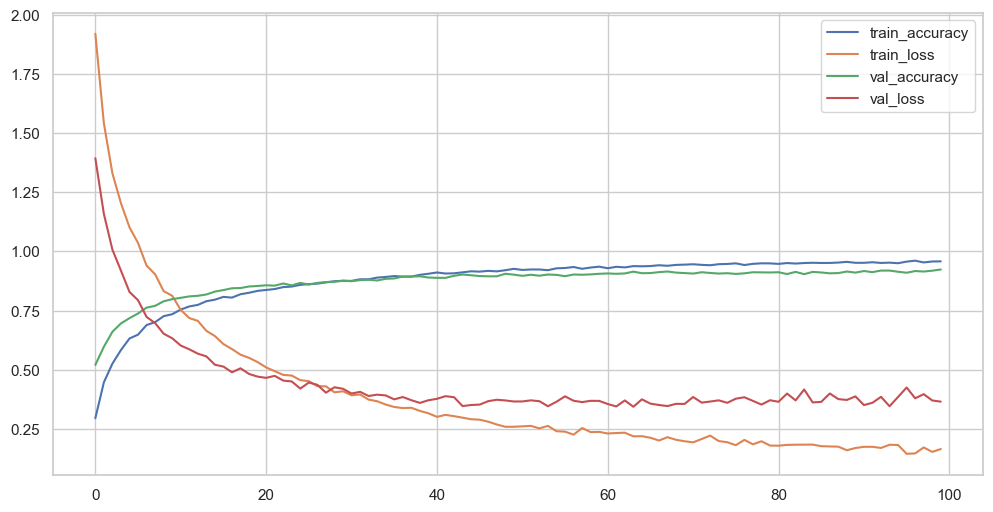

In [98]:
plotHistory(model_11_history)

GRAFICO FINALE DELLE RETI NEURALI

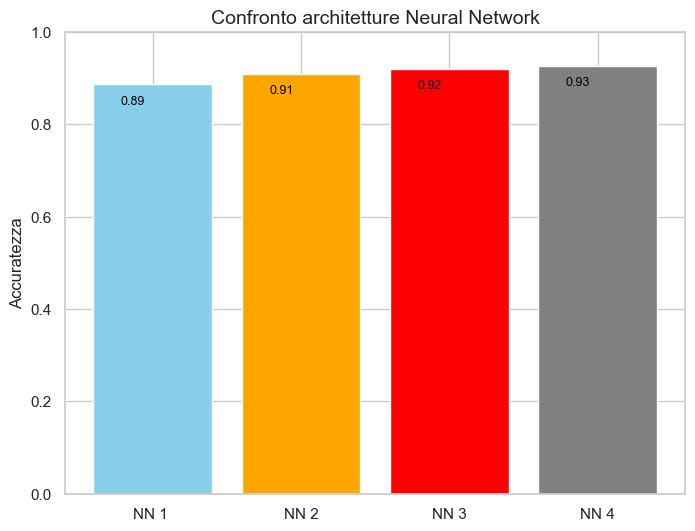

In [105]:
Grafico_Confronto_NN(nn1, nn6, nn11, nn7)